# **LONG STEPS in GRADIENT DESCENT METHODS**

## **Install**

### Firedrake

In [130]:
try:
    import google.colab  # noqa: F401
except ImportError:
    from firedrake import *
else:
    try:
        from firedrake import *
    except ImportError:
        !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh"
        !bash "/tmp/firedrake-install.sh"
        from firedrake import *

### Other

In [131]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

## **General functions**

### Constrained optimisation Firedrake code

In [135]:
def constrained_optimisation(nx=2**7, degree=1, gamma=2**32, max_iters=2**6):
    # UFL-ify gamma
    gamma = Constant(gamma)

    # Mesh
    mesh = UnitSquareMesh(nx, nx, quadrilateral=True)
    V = FunctionSpace(mesh, "Q", degree)

    # Constraint function f(x, y): circular bump
    x, y = SpatialCoordinate(mesh)
    cylinders = (
        ((0.4, 0.6), 0.3, 1.0),
        ((0.6, 0.4), 0.2, 0.8),
    )
    f = conditional((x - cylinders[0][0][0])**2 + (y - cylinders[0][0][1])**2 <= cylinders[0][1]**2, cylinders[0][2],
        conditional((x - cylinders[1][0][0])**2 + (y - cylinders[1][0][1])**2 <= cylinders[1][1]**2, cylinders[1][2],
        0.0
    ))

    # Functions
    u = Function(V)
    u_ = Function(V)
    v = TestFunction(V)

    # BCs
    bcs = DirichletBC(V, 0.0, "on_boundary")

    # Energy
    h1_norm = 0.5 * inner(grad(u_), grad(u_)) * dx
    constraint_viol = 0.5 * conditional(lt(u_, f), (u_ - f)**2, 0) * dx
    E = h1_norm + gamma * constraint_viol

    # Residual
    F = (
        inner(grad(u), grad(v))
      + gamma * conditional(lt(u_, f), (u - f) * v, 0)
    ) * dx

    # Newton's method
    energy = assemble(E)
    energies = [energy]
    print(GREEN % f"Energy: {energy}")
    for k in range(max_iters):
        # print(BLUE % f"Newton iterate {k+1}...")
        solve(F == 0, u, bcs)
        u_.assign(u)
        energy = assemble(E)
        energies += [energy]
        print(GREEN % f"Energy: {energy}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

    # Left: log energy error convergence
    energy_exact = min(energies) - abs(energies[-1] - energies[-2])
    energy_errors = [abs(energy - energy_exact) for energy in energies]

    ax1.semilogy(range(len(energy_errors)), energy_errors, marker='o')
    ax1.set_xlabel("Newton iterate")
    ax1.set_title("Energy errors")
    ax1.grid(True, which="both", ls="--", alpha=0.6)

    # Right: contour plot
    tpc = tripcolor(u, axes=ax2)
    # Create contour lines
    cntr = tricontour(u, levels=10, colors='w', linewidths=1.0, axes=ax2)
    ax2.set_aspect('equal')
    ax2.set_title("Contour plot")
    fig.colorbar(tpc, ax=ax2, orientation='vertical')
    for (center, width, height) in cylinders:
        circ = Circle(center, width, fill=False, color='k', linestyle='-', linewidth=2.0)
        ax2.add_patch(circ)

    plt.tight_layout()
    plt.show()

## **Motivation:** When Newton fails

We're all used to using Newton, and who can blame us?

When it works, the convergence is superb ($\mathcal{O}(C^{- n^2})$*).
However, it's not always the best tool for the job:

1. Newton–Kantorovich (i.e. the convergence result for Newton in the continuous setting) requires **local Lipschitz differentiability** of the residual. It's relatively easy to cook up situations where this is violated, e.g. say we want to minimise this funky functional:
$$
E(u) := \frac{1}{2}\int\|\nabla u\|^2 + \frac{\lambda}{2}\int_{u \le f}(u-f)^2.
$$
This kind of functional** is pretty much the simplest way to approach constrained optimisation, i.e. as $\lambda \to \infty$, we expect the minimiser of $E$ to be the $u$ that minimises $\int \|\nabla u\|^2$ subject to $u \ge f$.

    However, the (Fréchet) derivative of $E$,
    $$
    E'(u; v) = \int \nabla u \cdot \nabla v + \lambda\int_{u \le f}(u - f)v,
    $$
    is **not Lipschitz differentiable** in $H^1$.
    No surprise then, we see Newton really struggles to minimise $E$.

> **It's a bit technical about whether this result holds in the continuous setting, but let's just assume it does.*

> ***C.F. Nemystkii operators.*

Energy: 696906895.1071609
Energy: 12890.710975199065
Energy: 1279.341866305218
Energy: 149502.48704439096
Energy: 524217.3057128633
Energy: 15749.330759318875
Energy: 1095.9473851632272
Energy: 163.70296743472477
Energy: 33216.78610500322
Energy: 3842.005751835477
Energy: 120.10424475643951
Energy: 23.968466296730472
Energy: 34.30857582576243
Energy: 60.667092835121714
Energy: 23.919873323398175
Energy: 18.493354537856973
Energy: 90.82133566828763
Energy: 12.906727919686881
Energy: 9.27879468119835
Energy: 7.662638974231563
Energy: 10.109659367983282
Energy: 15.211361311280195
Energy: 7.844502118446891
Energy: 7.491459791298945
Energy: 11.126255551684306
Energy: 21.83449856522667
Energy: 12.321111298231267
Energy: 19.695659871548127
Energy: 8.68802838554225
Energy: 7.43553473373014
Energy: 7.942581588441606
Energy: 7.84951655979983
Energy: 7.872852258070288
Energy: 8.127119161996406
Energy: 8.456630550258236
Energy: 9.785753040656203
Energy: 7.035161159955918
Energy: 9.827533886936655


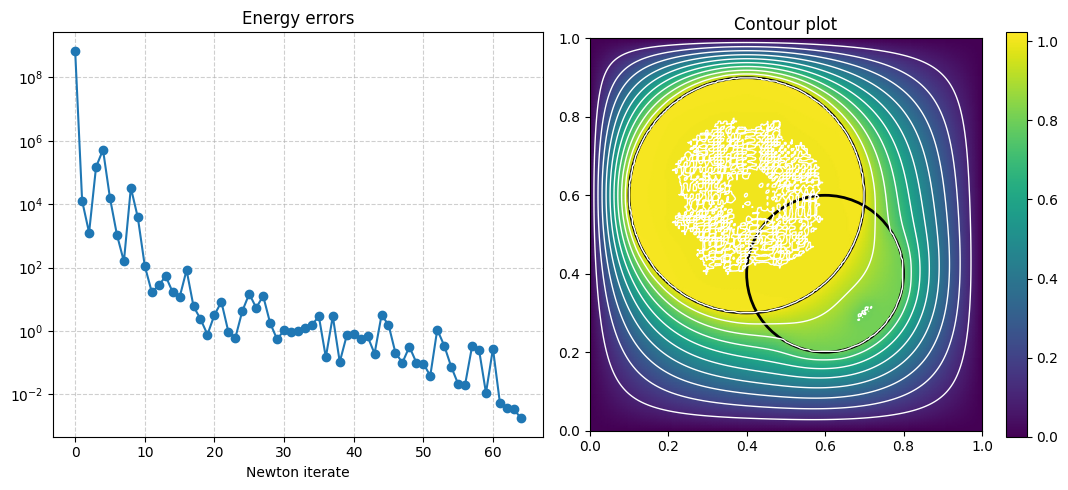

In [136]:
constrained_optimisation(nx=2**7, degree=1, gamma=2**32, max_iters=2**6)

2. Something we've all encountered:
Your initial guess might just lie **outside an attractive basin**.
This is especially common when you're looking at **highly nonlinear** problems with **multiple solutions**.

3. In Newton's method, the Jacobian, i.e. the linear operator we have to invert, changes at every iteration.
For instance, when minimising an energy functional, the Newton iterates are given by
$$
0 = E'(u_n; v) + E''(u_n; u_{n+1} - u_n, v).
$$
The Jacobian here is then $E''(u_n; \cdot, \cdot)$.

    The **assembly of this Jacobian** can massively **dominate the computation time**.
    This is especially true when you're at a high order, and you don't have so many tricks at your disposal to ensure this linear operator remains sparse.

Energy: 696964017.4677631
Energy: 589023.0282176352
Energy: 43522.487828276564
Energy: 2260.1594453840817
Energy: 287.18959588464395
Energy: 104.65795805537135
Energy: 89.95633282180269
Energy: 45.91706333351465
Energy: 28.411412361757133
Energy: 20.171480599525005
Energy: 12.298812235182986
Energy: 11.411671730111346
Energy: 17.32805570234971
Energy: 12.481823848931107
Energy: 9.991273860598277
Energy: 16.69282248714758
Energy: 15.27194618591934
Energy: 13.781616430088029
Energy: 15.13871495111502
Energy: 12.186430152713935
Energy: 15.455472617328681
Energy: 11.288588056841565
Energy: 12.41395100742873
Energy: 10.48201209258988
Energy: 7.973753547066146
Energy: 6.754033901220534
Energy: 6.7513671073893855
Energy: 6.752289676997837
Energy: 6.750250981814733
Energy: 6.750486784548314
Energy: 6.751023402685967
Energy: 6.749275019815887
Energy: 6.752409673329735


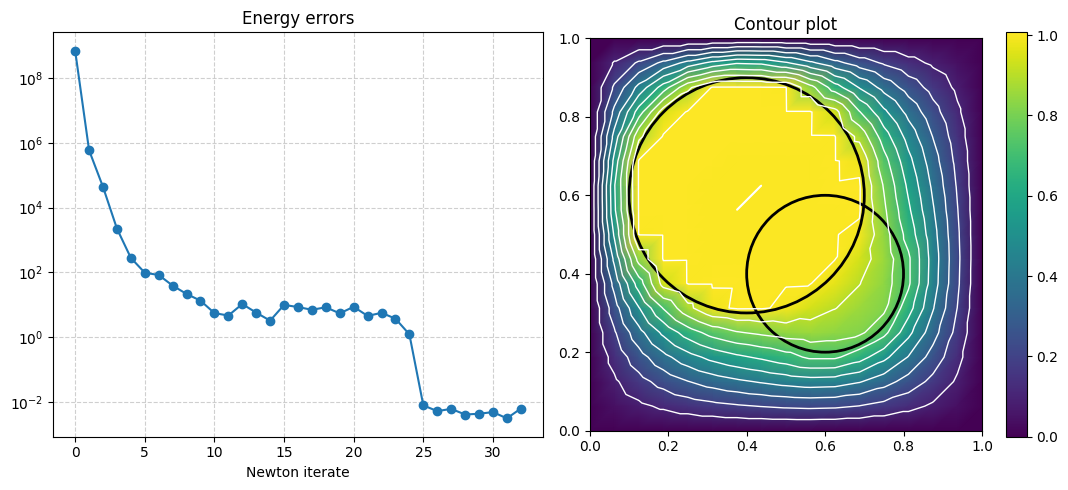

In [148]:
constrained_optimisation(nx=2**3, degree=14, gamma=2**32, max_iters=2**5)

Let's discuss a pretty robust alternative then...

## **Back to basics:** Gradient descent (GD)

Let's restrict our attention to energy minimisation problems.
You might not have seen GD in the function space setting before, but the idea's identical.
Instead of the update
$$
\mathbf{x}_{n+1} = \mathbf{x}_n - h\nabla E(\mathbf{x}_n),
$$
we have
$$
(u_{n+1}, v) = (u_n, v) - hE'(\mathbf{x}_n; v).
$$

Key facts:
- Converges for fixed step sizes in (0, 2/L), with L the Lipschitz constant of \nabla E.
- Only requires one lower level of regularity than Newton.
- The linear operator to invert in function spaces is the inner product; often identical across steps.
- Global convergence to a minimizer for convex energies regardless of start.